Fundamental Matrix (F):
 [[-6.84106513e-08  3.91163471e-07 -4.57560344e-05]
 [-4.45485970e-07 -2.92357121e-08  1.23790023e-03]
 [ 8.09378360e-05 -2.04951939e-03  1.00000000e+00]]


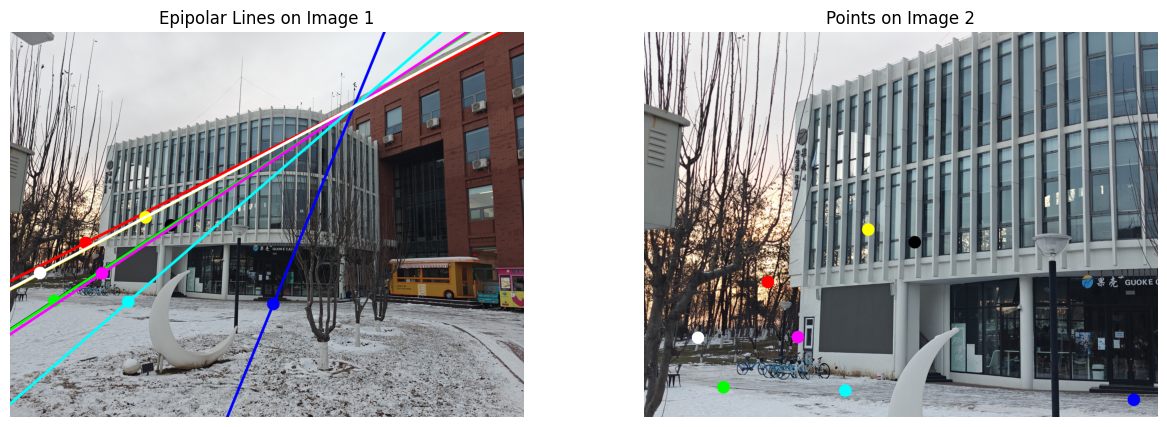

In [3]:
"""
基本矩阵F估计
"""
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

# 读取两张图像
img1 = cv2.imread('./photos/1.jpg', cv2.IMREAD_COLOR)
img2 = cv2.imread('./photos/2.jpg', cv2.IMREAD_COLOR)

# 将图像转换为灰度图
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 创建 SIFT 对象并检测和计算特征点
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)
descriptors1 = normalize(descriptors1, norm='l2')
descriptors2 = normalize(descriptors2, norm='l2')

# 使用 FLANN 匹配器进行特征匹配
index_params = dict(algorithm=1, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors2, k=2)

# 进行 ratio test 筛选好的匹配
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# 提取匹配点
points1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
points2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])

# 使用 RANSAC 方法计算基本矩阵
F, mask = cv2.findFundamentalMat(points1, points2, cv2.FM_RANSAC)

# 保留内点匹配
inliers1 = points1[mask.ravel() == 1]
inliers2 = points2[mask.ravel() == 1]

# 随机选择 8 对内点匹配
if len(inliers1) >= 8:
    indices = np.random.choice(len(inliers1), 8, replace=False)
    selected_inliers1 = inliers1[indices]
    selected_inliers2 = inliers2[indices]
else:
    selected_inliers1 = inliers1
    selected_inliers2 = inliers2

# 定义颜色列表
colors = [
    (0, 0, 0),        # 黑色
    (255, 0, 0),      # 红色
    (0, 255, 0),      # 绿色
    (0, 0, 255),      # 蓝色
    (255, 0, 255),    # 品红
    (255, 255, 0),    # 黄色
    (0, 255, 255),    # 青色
    (255, 255, 255)   # 白色
]

# 绘制极线函数
def draw_epipolar_lines(img1, img2, lines, pts1, pts2, colors):
    ''' 在两幅图像上绘制极线和匹配点 '''
    r, c, _ = img1.shape
    for r_line, pt1, pt2, color in zip(lines, pts1, pts2, colors):
        # 计算极线的两个端点
        x0, y0 = map(int, [0, -r_line[2] / r_line[1]])
        x1, y1 = map(int, [c, -(r_line[2] + r_line[0] * c) / r_line[1]])
        
        # 绘制极线
        img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 20)
        
        # 绘制匹配点
        center1 = tuple(map(int, pt1))
        center2 = tuple(map(int, pt2))
        img1 = cv2.circle(img1, center1, 50, color, -1)
        img2 = cv2.circle(img2, center2, 50, color, -1)
    return img1, img2

# 计算外极线
lines1 = cv2.computeCorrespondEpilines(selected_inliers2.reshape(-1, 1, 2), 2, F)
lines1 = lines1.reshape(-1, 3)

# 绘制图像上的极线和匹配点
img1_with_lines, img2_with_points = draw_epipolar_lines(
    img1.copy(), img2.copy(), lines1, 
    [tuple(map(int, pt)) for pt in selected_inliers1],
    [tuple(map(int, pt)) for pt in selected_inliers2],
    colors
)
# 打印基本矩阵
print("Fundamental Matrix (F):\n", F)
# 使用 Matplotlib 显示结果
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img1_with_lines, cv2.COLOR_BGR2RGB))
plt.title('Epipolar Lines on Image 1')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(img2_with_points, cv2.COLOR_BGR2RGB))
plt.title('Points on Image 2')
plt.axis('off')
plt.show()


正在读取: ./photos/3.jpg


d:\Users\Grimm\anaconda3\envs\vgg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26827 (\N{CJK UNIFIED IDEOGRAPH-68CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\vgg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\vgg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\vgg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Users\Grimm\anaconda3\envs\vgg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDE

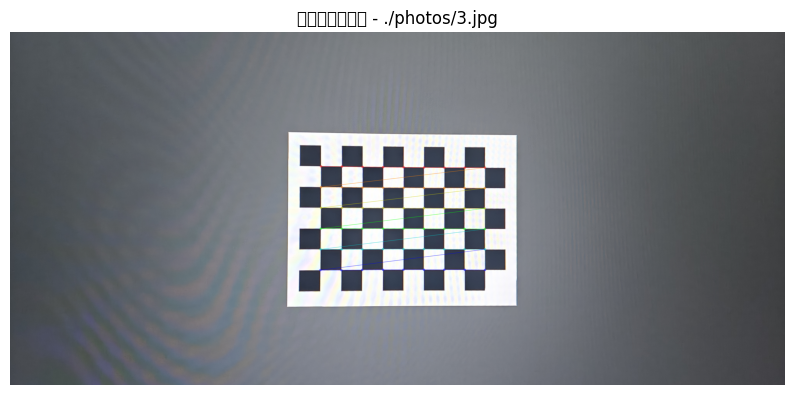

✓ ./photos/3.jpg: 成功检测到角点
正在读取: ./photos/4.jpg


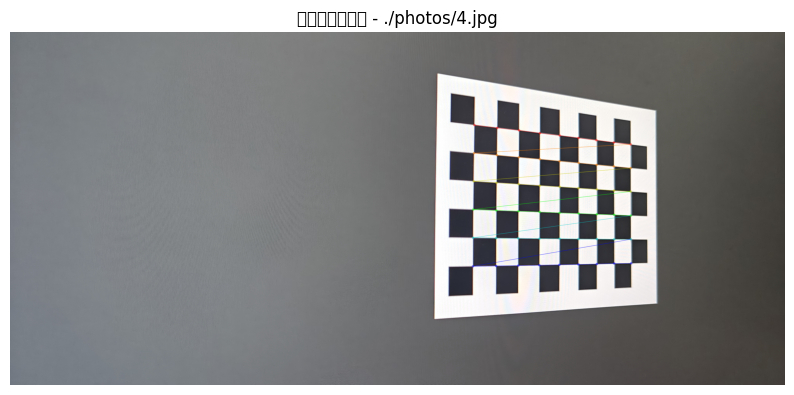

✓ ./photos/4.jpg: 成功检测到角点
正在读取: ./photos/5.jpg


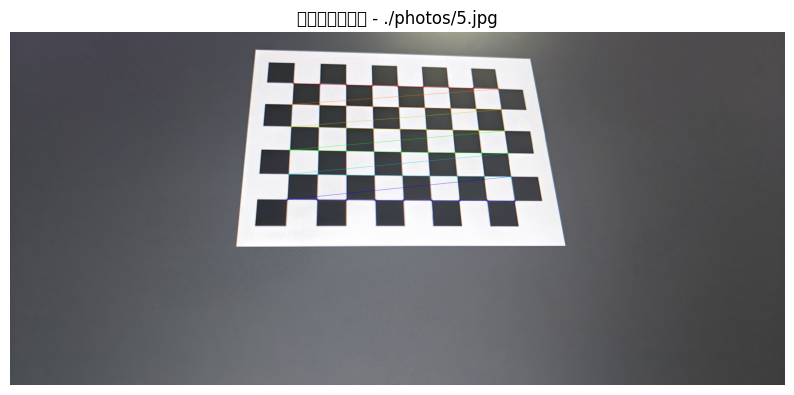

✓ ./photos/5.jpg: 成功检测到角点

1. OPENCV完整模型标定
图像数目: 3
焦距 fx: 2952.95
焦距 fy: 2953.74
主点 cx: 2076.28
主点 cy: 938.12
径向畸变: k1=-2.698938, k2=143.955002
切向畸变: p1=-0.000801, p2=-0.000703
三维点数: 162
误差中值: 0.0601
误差均值: 0.0553

2. 普通手机参数模型标定（焦距、主点、径向畸变和切向畸变参数）
图像数目: 3
焦距 fx: 2874.91
焦距 fy: 2872.75
主点 cx: 2065.82
主点 cy: 958.12
径向畸变: k1=0.112926, k2=-0.504302
切向畸变: p1=-0.000697, p2=-0.001022
三维点数: 162
误差中值: 0.0966
误差均值: 0.0915

3. 鱼眼相机模型标定
图像数目: 3
焦距 fx: 2943.50
焦距 fy: 2944.39
主点 cx: 2079.42
主点 cy: 944.86
径向畸变: k1=0.783610, k2=-5.809008
切向畸变: k3=27.119322, k4=-38.342420
三维点数: 162
误差中值: 0.0617
误差均值: 0.0559


In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import glob

# 使用绝对路径，并确保路径正确
file = './photos'

# 棋盘格的角点数目（内角点，行和列）
chessboard_size = (9, 6)

# 每个棋盘格格子的实际大小（单位：毫米）
square_size = 15

# 准备棋盘格的3D点坐标
objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)
objp *= square_size

# 用于存储所有图片的3D点和2D点
objpoints = []  # 3D点
imgpoints = []  # 2D点

# 选择3张示例图像
images = ['./photos/3.jpg', './photos/4.jpg', './photos/5.jpg']

# 逐个处理图像，检测棋盘格角点
for filename in images:
    img_path = filename
    print(f"正在读取: {img_path}")
    img = cv2.imread(img_path)
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 寻找棋盘格角点
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    
    if ret:
        # 精确化角点位置
        corners_refined = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        )
        
        objpoints.append(objp)
        imgpoints.append(corners_refined)
        
        # 绘制角点
        img_corners = cv2.drawChessboardCorners(img.copy(), chessboard_size, corners_refined, ret)
        
        # 显示结果
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
        plt.title(f'棋盘格检测结果 - {filename}')
        plt.axis('off')
        plt.show()
        
        print(f"✓ {filename}: 成功检测到角点")
    else:
        print(f"✗ {filename}: 未检测到棋盘格角点")

# 获取图像尺寸
image_size = gray.shape[::-1]

# 定义函数计算重投影误差
def calculate_reprojection_error(objpoints, imgpoints, rvecs, tvecs, mtx, dist, fisheye_flag=False):
    total_error = 0
    all_errors = []
    for i in range(len(objpoints)):
        if not fisheye_flag:
            imgpoints_proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        else:
            imgpoints_proj, _ = cv2.fisheye.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        error = cv2.norm(imgpoints[i], imgpoints_proj, cv2.NORM_L2) / len(imgpoints_proj)
        total_error += error
        all_errors.append(error)
    mean_error = total_error / len(objpoints)
    median_error = np.median(all_errors)
    return mean_error, median_error

print("\n" + "="*60)
print("1. OPENCV完整模型标定")
print("="*60)
ret, mtx_opencv, dist_opencv, rvecs_opencv, tvecs_opencv = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None,
    flags=cv2.CALIB_RATIONAL_MODEL
)
mean_error, median_error = calculate_reprojection_error(objpoints, imgpoints, rvecs_opencv, tvecs_opencv, mtx_opencv, dist_opencv)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {mtx_opencv[0, 0]:.2f}")
print(f"焦距 fy: {mtx_opencv[1, 1]:.2f}")
print(f"主点 cx: {mtx_opencv[0, 2]:.2f}")
print(f"主点 cy: {mtx_opencv[1, 2]:.2f}")
print(f"径向畸变: k1={dist_opencv[0][0]:.6f}, k2={dist_opencv[0][1]:.6f}")
print(f"切向畸变: p1={dist_opencv[0][2]:.6f}, p2={dist_opencv[0][3]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")

print("\n" + "="*60)
print("2. 普通手机参数模型标定（焦距、主点、径向畸变和切向畸变参数）")
print("="*60)
ret, mtx_phone, dist_phone, rvecs_phone, tvecs_phone = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None,
    flags=cv2.CALIB_FIX_K3
)
mean_error, median_error = calculate_reprojection_error(objpoints, imgpoints, rvecs_phone, tvecs_phone, mtx_phone, dist_phone)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {mtx_phone[0, 0]:.2f}")
print(f"焦距 fy: {mtx_phone[1, 1]:.2f}")
print(f"主点 cx: {mtx_phone[0, 2]:.2f}")
print(f"主点 cy: {mtx_phone[1, 2]:.2f}")
print(f"径向畸变: k1={dist_phone[0][0]:.6f}, k2={dist_phone[0][1]:.6f}")
print(f"切向畸变: p1={dist_phone[0][2]:.6f}, p2={dist_phone[0][3]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")

print("\n" + "="*60)
print("3. 鱼眼相机模型标定")
print("="*60)
objpoints_fisheye = [np.array(objp, dtype=np.float32).reshape(-1, 1, 3) for objp in objpoints]
imgpoints_fisheye = [np.array(imgp, dtype=np.float32).reshape(-1, 1, 2) for imgp in imgpoints]
K = np.zeros((3, 3))
D = np.zeros((4, 1))
flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW
rms, K, D, rvecs_fisheye, tvecs_fisheye = cv2.fisheye.calibrate(
    objpoints_fisheye, imgpoints_fisheye, image_size, K, D, flags=flags,
    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
)
mean_error, median_error = calculate_reprojection_error(objpoints_fisheye, imgpoints_fisheye, rvecs_fisheye, tvecs_fisheye, K, D, True)
print(f"图像数目: {len(objpoints)}")
print(f"焦距 fx: {K[0, 0]:.2f}")
print(f"焦距 fy: {K[1, 1]:.2f}")
print(f"主点 cx: {K[0, 2]:.2f}")
print(f"主点 cy: {K[1, 2]:.2f}")
print(f"径向畸变: k1={D[0][0]:.6f}, k2={D[1][0]:.6f}")
print(f"切向畸变: k3={D[2][0]:.6f}, k4={D[3][0]:.6f}")
print(f"三维点数: {len(objpoints) * len(objp)}")
print(f"误差中值: {median_error:.4f}")
print(f"误差均值: {mean_error:.4f}")